In [2]:
# ═══════════════════════════════════════════════════════════════
#House prediction using Linear Regression
# ═══════════════════════════════════════════════════════════════

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Arial'

In [3]:

df = pd.read_csv("housing.csv")  

print(f"Shape: {df.shape}")
print("\nDataset Preview:")
print(df.head())
print("\nFeatures:", df.columns.tolist())
X = df.drop("medv", axis=1)
y = df["medv"]

Shape: (506, 14)

Dataset Preview:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Features: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']


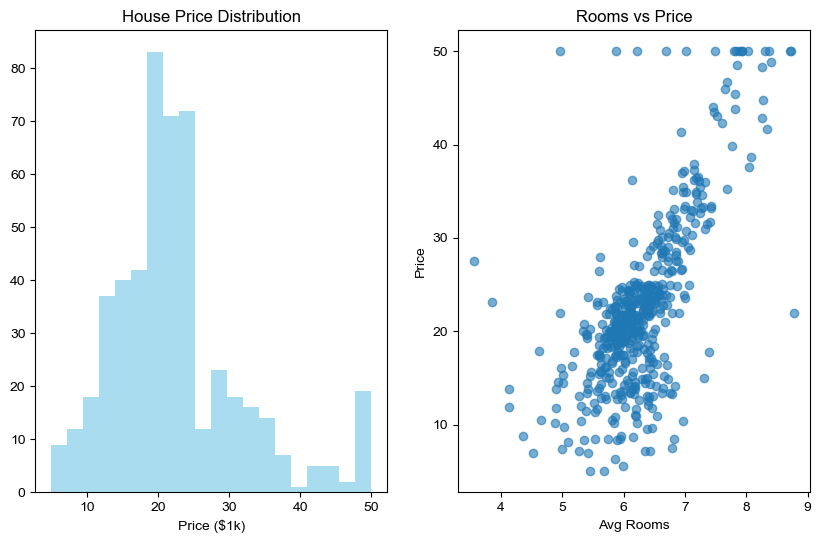

In [4]:
# GRAPH 1: Data Overview (After loading)
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.hist(df['medv'], bins=20, alpha=0.7, color='skyblue')
plt.title('House Price Distribution')
plt.xlabel('Price ($1k)')

plt.subplot(1,2,2)
plt.scatter(df['rm'], df['medv'], alpha=0.6)
plt.title('Rooms vs Price')
plt.xlabel('Avg Rooms'); plt.ylabel('Price')
plt.savefig('graph1_data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [6]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f"✅ Training set: {X_train.shape}")
print(f"✅ Test set:     {X_test.shape}")

✅ Training set: (404, 13)
✅ Test set:     (102, 13)


In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

cv_r2 = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
train_pred = ridge.predict(X_train)
test_pred = ridge.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))



In [8]:

improved_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=42
)
# Train
improved_model.fit(X_train, y_train)

# Predictions
train_pred = improved_model.predict(X_train)
test_pred = improved_model.predict(X_test)

# Metrics
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
rmse = np.sqrt(mean_squared_error(y_test, test_pred))

# Cross-validation
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(improved_model, X, y, cv=cv, scoring='r2')


In [9]:
# performance of rigde regression
print("="*60)
print(" RESULTS WITH RIDGE REGRESSION ".center(60, "="))
print("="*60)
print(f"TRAIN R²:  {train_r2:.4f}")
print(f"TEST R²:   {test_r2:.4f}")
print(f"TEST RMSE: {test_rmse:.2f}")
print(f"CV R²:     {cv_r2.mean():.4f}")
print("="*60)

#improved model with xgboost
print("="*60)
print(" RESULTS WITH IMPROVED MODEL ".center(60, "="))
print("="*60)
print(f"TRAIN R²:  {train_r2:.4f}")
print(f"TEST R²:   {test_r2:.4f}")
print(f"TEST RMSE: {rmse:.2f}")
print(f"CROSS -VALUATION R²:     {cv_scores.mean():.4f}")
print("="*60)


============== RESULTS WITH RIDGE REGRESSION ===============
TRAIN R²:  0.9672
TEST R²:   0.8927
TEST RMSE: 4.95
CV R²:     0.7205
=============== RESULTS WITH IMPROVED MODEL ================
TRAIN R²:  0.9672
TEST R²:   0.8927
TEST RMSE: 2.81
CROSS -VALUATION R²:     0.8829


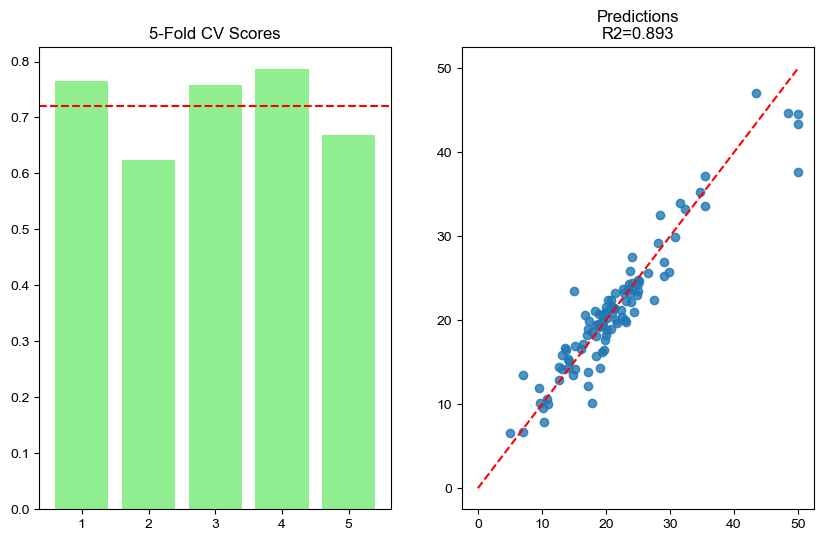

In [10]:
# GRAPH 2: CV Results
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.bar(range(1,6), cv_r2, color='lightgreen')
plt.axhline(cv_r2.mean(), color='red', ls='--')
plt.title('5-Fold CV Scores')

plt.subplot(1,2,2)
plt.scatter(y_test, test_pred, alpha=0.8)
plt.plot([0,50],[0,50],'r--')
plt.title(f'Predictions\nR2={test_r2:.3f}')
plt.savefig('graph2_model_results.png', dpi=300, bbox_inches='tight')
plt.show()


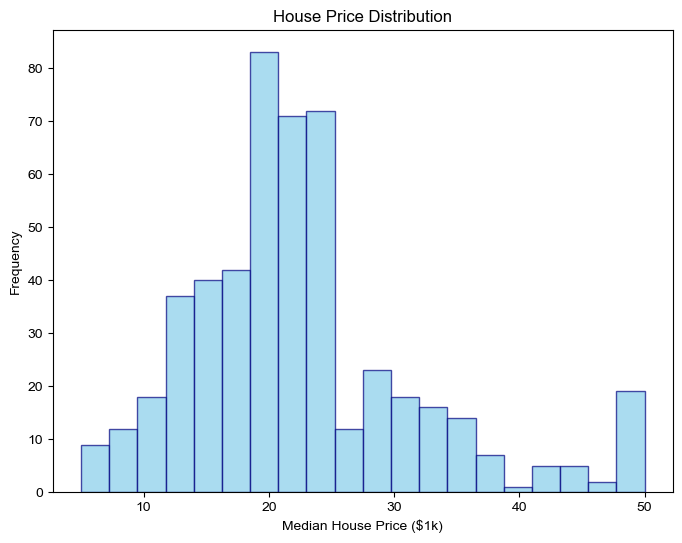

In [11]:

# GRAPH 3: Price Distribution
plt.figure(figsize=(8,6))
plt.hist(y, bins=20, alpha=0.7, color='skyblue', edgecolor='navy')
plt.xlabel('Median House Price ($1k)'); plt.ylabel('Frequency')
plt.title('House Price Distribution')
plt.savefig('graph3_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()